# Projeto Final - Machine Learning II

Aprofundar o modelo do Machine Learning I, utilizando as ferramentas da disciplina Machine Learning II e mantendo o dataset




# Importando bibliotecas no início

In [44]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_curve, auc, mean_squared_error, confusion_matrix, classification_report

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier


# Criando dados mockados para retomada de imóvel. Dados fictícios para treino.

## O início é parecido com o projeto da disciplina anterior, mas irei adaptar com base na disciplina Machine Learning II

In [4]:

np.random.seed(42)
n = 1000

data = {
    'renda_mensal': np.random.normal(5000, 2000, n).clip(500, None),
    'idade': np.random.randint(18, 75, n),
    'tempo_emprego_anos': np.random.exponential(5, n).clip(0, 40),
    'valor_imovel': np.random.normal(200000, 80000, n).clip(20000, None),
    'parcelas_atrasadas': np.random.poisson(1, n),
    'score_credito': np.random.uniform(300, 850, n),
    'tempo_inadimplencia_meses': np.random.randint(0, 24, n),
    'num_dependentes': np.random.randint(0, 6, n),
    'latitude': np.random.uniform(-30.0, -5.0, n),
    'longitude': np.random.uniform(-65.0, -35.0, n),
}

df = pd.DataFrame(data)
df['retomada'] = 0
idx = np.random.choice(n, size=int(0.15 * n), replace=False)
df.loc[idx, 'retomada'] = 1

scaler = MinMaxScaler()
cols = df.columns.difference(['retomada'])
df[cols] = scaler.fit_transform(df[cols])

df.to_csv('retomada_sintetica.csv', index=False)

print("Dataset criado e escrito: retomada_sintetica.csv")
print(df.head())

Dataset criado e escrito: retomada_sintetica.csv
   renda_mensal     idade  tempo_emprego_anos  valor_imovel  \
0      0.450079  0.964286            0.098141      0.300472   
1      0.346031  0.767857            0.126329      0.622560   
2      0.474818  0.857143            0.031205      0.241982   
3      0.618253  0.696429            0.479355      0.614733   
4      0.330319  0.178571            0.172367      0.817356   

   parcelas_atrasadas  score_credito  tempo_inadimplencia_meses  \
0                 0.6       0.488705                   0.347826   
1                 0.4       0.285227                   0.826087   
2                 0.4       0.722526                   0.000000   
3                 0.0       0.945380                   0.695652   
4                 0.0       0.917110                   0.478261   

   num_dependentes  latitude  longitude  retomada  
0              0.4  0.588495   0.188768         1  
1              0.6  0.064083   0.701416         0  
2            

# Verificando a proporção

In [5]:
df['retomada'].value_counts(normalize=True)

retomada
0    0.85
1    0.15
Name: proportion, dtype: float64

# Gerando a matriz de correlação

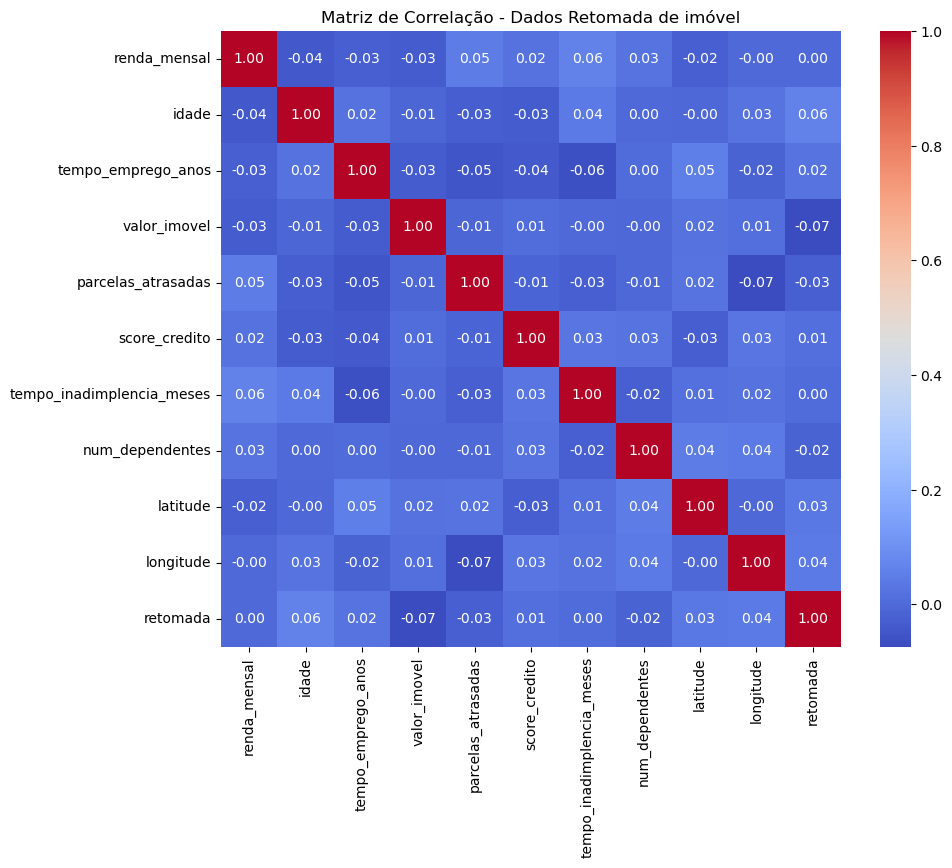

In [6]:

corr = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title('Matriz de Correlação - Dados Retomada de imóvel')
plt.show()

## Foi escolhida a proporção de 15% de retomada e 80/20 para treino e teste.

In [7]:
# FEATURES E TARGET

X = df.drop('retomada', axis=1)
y = df['retomada']

# TREINO E TESTE

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Tamanho treino:", X_train.shape, "tamanho teste:", X_test.shape)
print("Proporção de retomada no conjunto de treino:", y_train.mean())
print("Proporção de retomada no conjunto de teste:", y_test.mean())

Tamanho treino: (800, 10) tamanho teste: (200, 10)
Proporção de retomada no conjunto de treino: 0.15
Proporção de retomada no conjunto de teste: 0.15


In [46]:

numeric_features = X.columns.tolist() 

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), 
    ('scaler', StandardScaler())                    
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features)
])


X_train_pre = preprocessor.fit_transform(X_train)
X_test_pre = preprocessor.transform(X_test)

print("X_train_pre:", X_train_pre.shape, "X_test_pre:", X_test_pre.shape)
print("Sem valores NaN após preprocessamento:",
      np.isnan(X_train_pre).sum(), np.isnan(X_test_pre).sum())


pipe_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

pipe_rf.fit(X_train, y_train)
print("Acurácia RandomForest (pré-process + treino):", pipe_rf.score(X_test, y_test))

X_train_pre: (800, 10) X_test_pre: (200, 10)
Sem valores NaN após preprocessamento: 0 0
Acurácia RandomForest (pré-process + treino): 0.85


In [47]:
svm_base = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('svm', SVC(random_state=42))
])
svm_base.fit(X_train, y_train)

ypred_svm = svm_base.predict(X_test)
print("SVM Test accuracy:", accuracy_score(y_test, ypred_svm))

SVM Test accuracy: 0.85


# Criando a função de métricas

In [48]:
def metricas_modelo(modelo, num_cv):

    y_pred_treino = modelo.predict(X_train)
    y_pred_teste = modelo.predict(X_test)   

    acc_treino = accuracy_score(y_train, y_pred_treino)
    acc_teste = accuracy_score(y_test, y_pred_teste)

    cv_scores = cross_val_score(modelo, X_train, y_train, cv=num_cv, scoring='accuracy')

    print(f"Acurácia Treino: {acc_treino:.3f}")
    print(f"Acurácia Teste: {acc_teste:.3f}")
    print(np.round(cv_scores, 4))
    print(classification_report(y_test, y_pred_teste))

In [20]:
rf_base = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('rf', RandomForestClassifier(random_state=42))
])
rf_base.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['renda_mensal', 'idade',
                                                   'tempo_emprego_anos',
                                                   'valor_imovel',
                                                   'parcelas_atrasadas',
                                                   'score_credito',
                                                   'tempo_inadimplencia_meses',
                                                   'num_dependentes',
                                                   'latitude',
                                                   'longitude'])])),
                ('rf', RandomForestClassifier(random_state=42))])

In [23]:
metricas_modelo(rf_base, num_cv=3)

Acurácia Treino: 1.000
Acurácia Teste: 0.850
[0.8502 0.8502 0.8459]
              precision    recall  f1-score   support

           0       0.85      1.00      0.92       170
           1       0.00      0.00      0.00        30

    accuracy                           0.85       200
   macro avg       0.42      0.50      0.46       200
weighted avg       0.72      0.85      0.78       200



c:\Users\C127118\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\C127118\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\C127118\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


# Buscando melhores parâmetros

In [30]:
grid_parametros = {
    'svm__C': [0.001, 0.01, 0.1, 1, 10],
    'svm__gamma': [0.001, 0.01, 0.1, 1, 10],
    'svm__kernel': ['rbf', 'linear', 'poly']
}

grid_search = GridSearchCV(estimator=svm_base, param_grid=grid_parametros, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Melhores parâmetros:", grid_search.best_params_)
print("Melhor acurácia CV:", grid_search.best_score_.round(4))

Melhores parâmetros: {'svm__C': 0.001, 'svm__gamma': 0.001, 'svm__kernel': 'rbf'}
Melhor acurácia CV: 0.85


# Verificando métricas dos parâmetros otimizados

In [49]:
best_params = grid_search.best_params_
print("Melhores parâmetros SVM (Grid Search):", best_params)
print("Melhor acurácia CV (Grid Search):", grid_search.best_score_.round(4))

best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)

acc = accuracy_score(y_test, y_pred_best)
prec = precision_score(y_test, y_pred_best, zero_division=0)
rec = recall_score(y_test, y_pred_best, zero_division=0)
f1 = f1_score(y_test, y_pred_best, zero_division=0)
cm = confusion_matrix(y_test, y_pred_best)

print("\nMétricas no conjunto de teste para melhor SVM:")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")
print("Confusion Matrix:\n", cm)

print("\nClassification report:")
print(classification_report(y_test, y_pred_best, zero_division=0))

# opcional: reforço de cross-validation do modelo final
cv_final = cross_val_score(best_model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
print("\nCV 5-fold do melhor modelo (treino):", np.round(cv_final, 4))
print("CV mean:", np.mean(cv_final).round(4), "std:", np.std(cv_final).round(4))

Melhores parâmetros SVM (Grid Search): {'svm__C': 0.001, 'svm__gamma': 0.001, 'svm__kernel': 'rbf'}
Melhor acurácia CV (Grid Search): 0.85

Métricas no conjunto de teste para melhor SVM:
Accuracy:  0.8500
Precision: 0.0000
Recall:    0.0000
F1-score:  0.0000
Confusion Matrix:
 [[170   0]
 [ 30   0]]

Classification report:
              precision    recall  f1-score   support

           0       0.85      1.00      0.92       170
           1       0.00      0.00      0.00        30

    accuracy                           0.85       200
   macro avg       0.42      0.50      0.46       200
weighted avg       0.72      0.85      0.78       200


CV 5-fold do melhor modelo (treino): [0.85 0.85 0.85 0.85 0.85]
CV mean: 0.85 std: 0.0


# Verificar matriz de confusão do melhor modelo encontrado (Modelo Tunado)

Confusion matrix (Modelo Tunado)):
[[170   0]
 [ 30   0]]


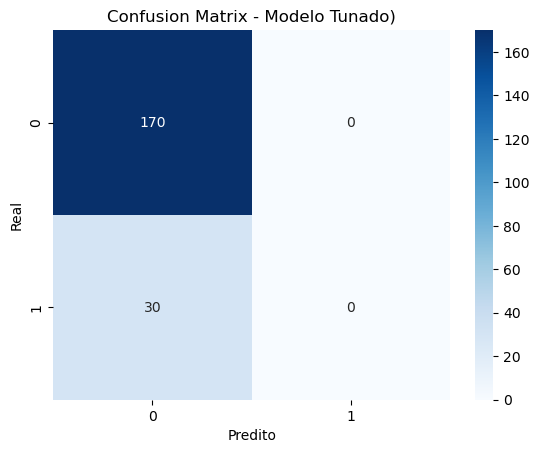

In [52]:

y_pred_best = best_model.predict(X_test)
cm_best = confusion_matrix(y_test, y_pred_best)

print("Confusion matrix (Modelo Tunado)):")
print(cm_best)

# opcional: plot
sns.heatmap(cm_best, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Confusion Matrix - Modelo Tunado)")
plt.show()

# Verificando demais modelos

In [40]:

def evaluate_model_and_get_metrics(model_pipeline, X_train, y_train, X_test, y_test, num_cv=3):
    model_pipeline.fit(X_train, y_train)

    y_pred_train = model_pipeline.predict(X_train)
    y_pred_test = model_pipeline.predict(X_test)

    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)

    cv_scores = cross_val_score(model_pipeline, X_train, y_train, cv=num_cv, scoring='accuracy', n_jobs=-1)

    report_test = classification_report(y_test, y_pred_test, output_dict=True)

    return {
        'Accuracy_Train': acc_train,
        'Accuracy_Test': acc_test,
        'CV_Mean_Accuracy': np.mean(cv_scores),
        'CV_Std_Accuracy': np.std(cv_scores),
        'Classification_Report_Test': report_test
    }

models = {
    'Naive Bayes': Pipeline([('preprocessor', preprocessor), ('model', GaussianNB())]),
    'KNN': Pipeline([('preprocessor', preprocessor), ('model', KNeighborsClassifier())]),
    'SVM (Base)': Pipeline([('preprocessor', preprocessor), ('model', SVC(random_state=42))]),
    'Decision Tree': Pipeline([('preprocessor', preprocessor), ('model', DecisionTreeClassifier(random_state=42))]),
    'Random Forest (Base)': Pipeline([('preprocessor', preprocessor), ('model', RandomForestClassifier(random_state=42))]),
    'Logistic Regression': Pipeline([('preprocessor', preprocessor), ('model', LogisticRegression(random_state=42, solver='liblinear', max_iter=1000))])
}

if LGBMClassifier is not None:
    models['LightGBM'] = Pipeline([('preprocessor', preprocessor), ('model', LGBMClassifier(random_state=42, verbose=-1))])

if XGBClassifier is not None:
    models['XGBoost'] = Pipeline([('preprocessor', preprocessor), ('model', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'))])

all_metrics = {}

print("Starting model training and evaluation...\n")
for name, model_pipeline in models.items():
    print(f"--- Training and evaluating: {name} ---")
    metrics = evaluate_model_and_get_metrics(model_pipeline, X_train, y_train, X_test, y_test)
    all_metrics[name] = metrics
    print(f"Accuracy Test for {name}: {metrics['Accuracy_Test']:.3f}\n")

print("\n--- Comparative Metrics Summary ---")
metrics_df = pd.DataFrame([
    {
        'Model': model_name,
        'Accuracy_Train': metrics['Accuracy_Train'],
        'Accuracy_Test': metrics['Accuracy_Test'],
        'CV_Mean_Accuracy': metrics['CV_Mean_Accuracy']
    }
    for model_name, metrics in all_metrics.items()
])
print(metrics_df.sort_values(by='Accuracy_Test', ascending=False).to_markdown(index=False))

print("\n--- Detailed Classification Reports (Test Set) ---")
for model_name, metrics in all_metrics.items():
    print(f"\nModel: {model_name}")
    report = pd.DataFrame(metrics['Classification_Report_Test']).transpose()
    print(report.to_markdown(floatfmt=".3f"))

Starting model training and evaluation...

--- Training and evaluating: Naive Bayes ---
Accuracy Test for Naive Bayes: 0.850

--- Training and evaluating: KNN ---
Accuracy Test for KNN: 0.845

--- Training and evaluating: SVM (Base) ---
Accuracy Test for SVM (Base): 0.850

--- Training and evaluating: Decision Tree ---
Accuracy Test for Decision Tree: 0.745

--- Training and evaluating: Random Forest (Base) ---
Accuracy Test for Random Forest (Base): 0.850

--- Training and evaluating: Logistic Regression ---
Accuracy Test for Logistic Regression: 0.850

--- Training and evaluating: LightGBM ---
Accuracy Test for LightGBM: 0.850

--- Training and evaluating: XGBoost ---
Accuracy Test for XGBoost: 0.820


--- Comparative Metrics Summary ---
| Model                |   Accuracy_Train |   Accuracy_Test |   CV_Mean_Accuracy |
|:---------------------|-----------------:|----------------:|-------------------:|
| Naive Bayes          |          0.85    |           0.85  |           0.85     |
|

# Escolhendo melhor modelo

In [45]:

confusion_matrices = {}

print("Matrizes de Confusão por Modelo:\n")
for nome, pipeline in models.items():
    y_pred = pipeline.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices[nome] = cm
    print(f"{nome}:")
    print(cm)
    print()


best_acc_row = metrics_df.sort_values(by=['Accuracy_Test', 'CV_Mean_Accuracy'], ascending=False).iloc[0]
best_model_name = best_acc_row['Model']
best_accuracy = best_acc_row['Accuracy_Test']
best_cv_mean = best_acc_row['CV_Mean_Accuracy']

print("Melhor modelo identificado:")
print(f"Modelo: {best_model_name}")
print(f"Acurácia teste: {best_accuracy:.4f}")
print(f"CV média: {best_cv_mean:.4f}")
print("Matriz de confusão do melhor modelo:")
print(confusion_matrices[best_model_name])

Matrizes de Confusão por Modelo:

Naive Bayes:
[[170   0]
 [ 30   0]]

KNN:
[[169   1]
 [ 30   0]]

SVM (Base):
[[170   0]
 [ 30   0]]

Decision Tree:
[[146  24]
 [ 27   3]]

Random Forest (Base):
[[170   0]
 [ 30   0]]

Logistic Regression:
[[170   0]
 [ 30   0]]

LightGBM:
[[168   2]
 [ 28   2]]

XGBoost:
[[163   7]
 [ 29   1]]

Melhor modelo identificado:
Modelo: Naive Bayes
Acurácia teste: 0.8500
CV média: 0.8500
Matriz de confusão do melhor modelo:
[[170   0]
 [ 30   0]]


# Conclusão

Por serem mantidos os dados mockados, muitos modelos passaram "ilesos" pela matriz de confusão.

Ainda assim, o melhor modelo definido foi:

Melhor modelo identificado:


#  Modelo: Naive Bayes e Modelo Tunado
# Acurácia teste: 0.8500
# CV média: 0.8500
# Matriz de confusão do melhor modelo:
# [[170   0]
#  [ 30   0]]

 Foi importante ajustes os parâmetros, pois isso diminuiu o Overfiting apresentado na disciplina anterior usando apenas KNN e RandonForest.

 Usei, ao máximo, os modelos explorados nas aulas e os notebooks disponibilizados. Tentei replicar os modelos e com base neles, entender melhor o assunto. Até pela melhor replicabilidade, optei por manter o dataset mockado. E não utilizei EDA, pois diminuiria ainda mais as colunas e não havia nenhum dado de correlação relevante.